In [1]:
FILTER_ZEROS = False
THRESHOLD = 1

In [2]:
import pandas as pd
import glob
import numpy as np

files = glob.glob("./unconstrained_results/*.parquet")

df_all = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print(df_all.shape)
df_all.head()

(36530, 136)


,Date,Origin,Destination,Flight_Sequence,Scheduled_Flights,Base_Price_per_kg,Price_Index,Final_True_Demand,Final_Constrained_Bookings,Is_Censored,...,Naive_Express_Est,EM_Express_Est,MARSS_Express_Est,EMXPrice_Express_Est,MARSSXPrice_Express_Est,Naive_Spot_Est,EM_Spot_Est,MARSS_Spot_Est,EMXPrice_Spot_Est,MARSSXPrice_Spot_Est
0,2016-01-01,CAN,CGO,1,1,2.6,1.030909,17142.0,17142.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,CAN,CGO,1,1,2.6,1.091678,10182.0,10182.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-03,CAN,CGO,1,1,2.6,0.782443,8079.0,8079.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-04,CAN,CGO,1,1,2.6,0.835538,16226.0,16226.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-05,CAN,CGO,1,1,2.6,1.013439,11768.0,11768.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# 1. Define your estimation columns
est_columns = ['Naive_Est', 'EM_Est', 'MARSS_Est', 'EMXPrice_Est', 'MARSSXPrice_Est']

# 2. Function to trim the burn-in period for a single OD pair
def trim_burn_in(df_group):
    # Find the first row where ALL estimation columns have valid (non-NaN) data
    # If some models burn-in faster than others, this ensures we wait for the slowest one
    valid_mask = df_group[est_columns].notna().all(axis=1)
    
    if not valid_mask.any():
        return pd.DataFrame() # Return empty if the models never converged
        
    first_valid_idx = valid_mask.idxmax() 
    
    # Return the dataframe from the first valid index to the end
    return df_group.loc[first_valid_idx:].copy()

# 3. Apply the trimming per OD pair
df_trimmed = df_all.groupby(['Origin', 'Destination'], as_index=False, group_keys=False).apply(trim_burn_in)

# 4. (Optional but recommended) Fill any remaining NaNs AFTER the burn-in
# If your models output NaN on later days simply because the day was uncensored, 
# you still need to fill those with the observed bookings so the forecaster doesn't crash.
for col in est_columns:
    df_trimmed[col] = df_trimmed[col].fillna(df_trimmed['Final_Constrained_Bookings'])

print(f"Original shape: {df_all.shape}")
print(f"Trimmed shape: {df_trimmed.shape}")

df_all = df_trimmed.reset_index(drop=True)

KeyError: "None of [Index(['Naive_Est', 'EM_Est', 'MARSS_Est', 'EMXPrice_Est', 'MARSSXPrice_Est'], dtype='object')] are in the [columns]"

In [ ]:
models = ["Naive_Est", "EM_Est", "MARSS_Est", "EMXPrice_Est", "MARSSXPrice_Est"]

results = []

# Evaluate route-by-route first
for col in models:

    route_metrics = []

    for (o, d), g in df_all.groupby(["Origin", "Destination"]):

        y_true = g["Final_True_Demand"]
        y_pred = g[col]

        mask = y_pred.notna()

        if mask.sum() == 0:
            continue

        yt = y_true[mask].values
        yp = y_pred[mask].values

        mse = np.mean((yt - yp) ** 2)
        mae = np.mean(np.abs(yt - yp))
        rmse = np.sqrt(mse)

        # Optional filter:
        # remove OD pairs that are essentially zero-error / trivial
        if FILTER_ZEROS and (mae + mse + rmse < THRESHOLD):
            print(f"Skipping OD pair ({o} -> {d}) due to low error: MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse:.4f}")
            continue

        route_metrics.append((mae, mse, rmse))

    # Aggregate remaining OD pairs
    if len(route_metrics) == 0:
        avg_mae = np.nan
        avg_mse = np.nan
        avg_rmse = np.nan
        n_routes = 0
    else:
        arr = np.array(route_metrics)
        avg_mae = arr[:, 0].mean()
        avg_mse = arr[:, 1].mean()
        avg_rmse = arr[:, 2].mean()
        n_routes = len(route_metrics)

    results.append({
        "Model": col,
        "Routes_Used": n_routes,
        "MAE": avg_mae,
        "MSE": avg_mse,
        "RMSE": avg_rmse
    })

metrics_df = pd.DataFrame(results)
metrics_df

,Model,Routes_Used,MAE,MSE,RMSE
0,Naive_Est,90,1444.816805,4.576134e+07,5193.454941
1,EM_Est,90,946.291447,2.213680e+07,3613.765128
2,MARSS_Est,90,911.095541,1.852126e+07,3325.320785
3,EMXPrice_Est,90,932.894845,2.142464e+07,3555.054579
4,MARSSXPrice_Est,90,894.059211,1.807705e+07,3280.192615


In [ ]:
pair_results = []

for (o, d), g in df_all.groupby(["Origin", "Destination"]):

    y_true = g["Final_True_Demand"]

    row = {
        "Origin": o,
        "Destination": d
    }

    for col in models:

        mask = g[col].notna()

        mse = np.mean((y_true[mask] - g[col][mask])**2)
        mae = np.mean(np.abs(y_true[mask] - g[col][mask]))

        row[f"{col}_MAE"] = mae
        row[f"{col}_MSE"] = mse

    pair_results.append(row)

pair_df = pd.DataFrame(pair_results)
pair_df.to_csv("pairwise_metrics.csv", index=False)
pair_df.head()

,Origin,Destination,Naive_Est_MAE,Naive_Est_MSE,EM_Est_MAE,EM_Est_MSE,MARSS_Est_MAE,MARSS_Est_MSE,EMXPrice_Est_MAE,EMXPrice_Est_MSE,MARSSXPrice_Est_MAE,MARSSXPrice_Est_MSE
0,CAN,CGO,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
1,CAN,HKG,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
2,CAN,JFK,4490.766727,1.723174e+08,2996.961335,8.706093e+07,2864.420630,7.265226e+07,2960.940773,8.467570e+07,2827.633778,7.166799e+07
3,CAN,LAX,2098.029197,6.636293e+07,1350.981743,3.359147e+07,1313.893616,2.921548e+07,1331.305915,3.258019e+07,1294.236553,2.856621e+07
4,CAN,NRT,1014.294404,2.314463e+07,642.186024,1.044771e+07,613.447764,8.852272e+06,632.035368,1.013109e+07,598.805528,8.535167e+06


In [ ]:
pair_df["Best_Model"] = pair_df[
    ["Naive_Est_MAE", "EM_Est_MAE", "MARSS_Est_MAE", "EMXPrice_Est_MAE", "MARSSXPrice_Est_MAE"]
].idxmin(axis=1)

pair_df[["Origin", "Destination", "Best_Model"]]

,Origin,Destination,Best_Model
0,CAN,CGO,Naive_Est_MAE
1,CAN,HKG,Naive_Est_MAE
2,CAN,JFK,MARSSXPrice_Est_MAE
3,CAN,LAX,MARSSXPrice_Est_MAE
4,CAN,NRT,MARSSXPrice_Est_MAE
...,...,...,...
85,SIN,LAX,MARSSXPrice_Est_MAE
86,SIN,NRT,MARSSXPrice_Est_MAE
87,SIN,ORD,MARSSXPrice_Est_MAE
88,SIN,PEK,MARSSXPrice_Est_MAE


In [ ]:
# Create a mapping that checks if an OD pair was EVER censored
od_censored_status = df_all.groupby(['Origin', 'Destination'])['Is_Censored'].any().reset_index()
od_censored_status.rename(columns={'Is_Censored': 'Ever_Censored'}, inplace=True)

# Merge this status back to the main DataFrame
df_all = df_all.merge(od_censored_status, on=['Origin', 'Destination'])

# Split into Group A (Constrained) and Group B (Unconstrained)
group_a = df_all[df_all['Ever_Censored'] == True].copy()
group_b = df_all[df_all['Ever_Censored'] == False].copy()

# Optional: drop the helper column to keep things clean
group_a.drop(columns=['Ever_Censored'], inplace=True)
group_b.drop(columns=['Ever_Censored'], inplace=True)

print(f"Group A (Constrained) shape: {group_a.shape}")
print(f"Group B (Unconstrained) shape: {group_b.shape}")

Group A (Constrained) shape: (259752, 30)
Group B (Unconstrained) shape: (36168, 30)


/tmp/ipykernel_23794/3819989706.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Group', y='Final_True_Demand', palette='Set2')


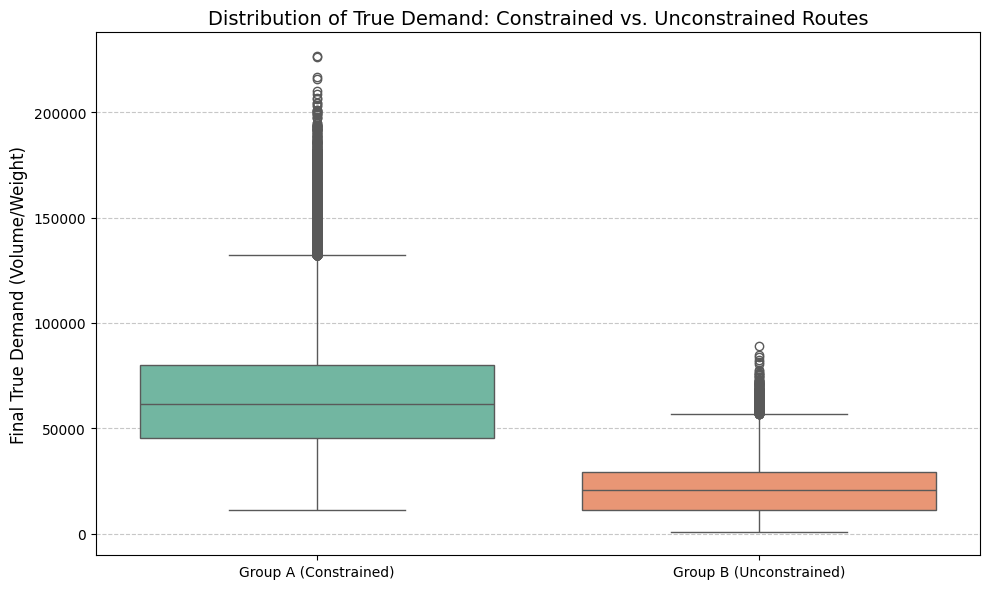

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a combined temporary DataFrame just for the plot
plot_data = pd.DataFrame({
    'Group': ['Group A (Constrained)'] * len(group_a) + ['Group B (Unconstrained)'] * len(group_b),
    'Final_True_Demand': pd.concat([group_a['Final_True_Demand'], group_b['Final_True_Demand']])
})

# Generate the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x='Group', y='Final_True_Demand', palette='Set2')

# Add titles and labels
plt.title('Distribution of True Demand: Constrained vs. Unconstrained Routes', fontsize=14)
plt.ylabel('Final True Demand (Volume/Weight)', fontsize=12)
plt.xlabel('')

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()